In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
    generate_env,
)
from tqdm import tqdm

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
rho_sign_flipped = np.array([1.0, -0.6, 0.0, 0.6])
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])

rho_lr_grid = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
observation_noise_private_grid = [0.1, 0.3, 1]

base_conditions = {
    "perfectly_calibrated": {
        "label": "SG-ICM\ncalibrated",
        "params": {
            "rho_update_rule": None,
            "rho": rho_true,
            "model_type": "SG-ICM",
        }
    },
    "sign_flipped": {
        "label": "SG-ICM\nflipped",
        "params": {
            "rho_update_rule": None,
            "rho": rho_sign_flipped,
            "model_type": "SG-ICM",
        }
    },
    "asocial": {
        "label": "AS",
        "params": {
            "rho_update_rule": None,
            "rho": rho_zero,
            "model_type": "SG-ICM",
        }
    },
    # "sg_calibrated": {
    #     "label": "SG calibrated\n(0.01, 20, 20)",
    #     "params": {
    #         "model_type": "SG",
    #         "rho_update_rule": None,
    #         "observation_noise_social": [0.01, 20, 20],
    #         "rho": rho_zero,
    #     }
    # },
    # "sg_flipped": {
    #     "label": "SG flipped\n(20 0.01 0.01)",
    #     "params": {
    #         "model_type": "SG",
    #         "rho_update_rule": None,
    #         "observation_noise_social": [20, 0.01, 0.01],
    #         "rho": rho_zero,
    #     }
    # }
}

learning_conditions = {}
for rho_lr in rho_lr_grid:
    for obs_noise in observation_noise_private_grid:
        key = f"landmarks_corr_lr{rho_lr}_noise{obs_noise}"
        learning_conditions[key] = {
            "label": f"lr={rho_lr} | noise={obs_noise}",
            "params": {
                "rho_update_rule": "landmarks_corr",
                "rho_update_kwargs": {"rho_lr": rho_lr},
                "rho": rho_zero,
                "model_type": "SG-ICM",
                "rho_update_init": 0.0,
                "observation_noise_private": obs_noise,
            }
        }

conditions = {**base_conditions, **learning_conditions}
update_conditions = list(learning_conditions.keys())


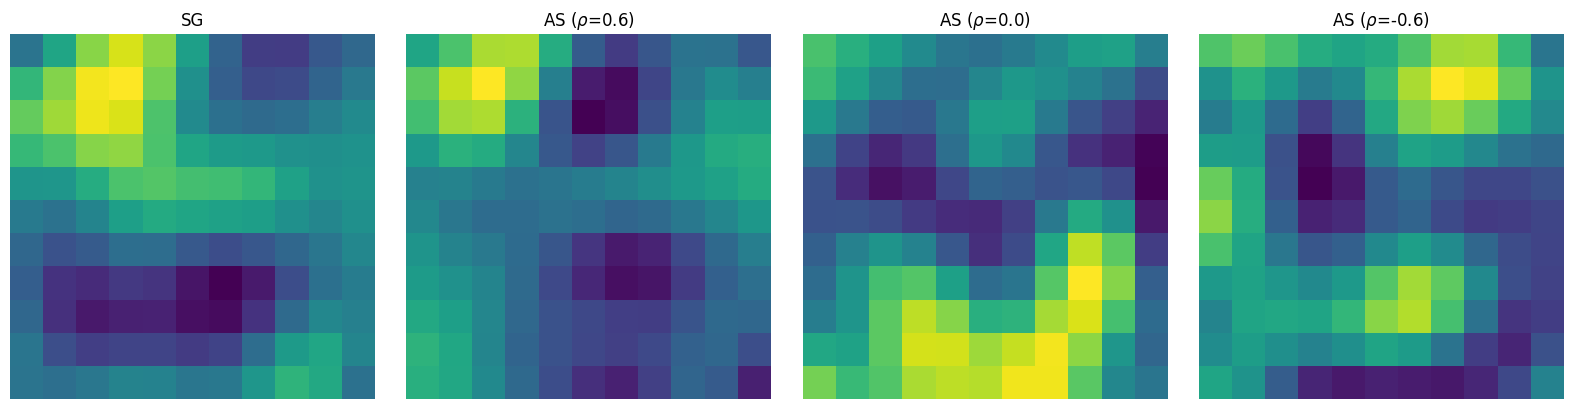

In [5]:
n_children = corr_matrix.shape[0] - 1
seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho$={_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Run the model


In [6]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=rho_zero,
    rho_update_rule="landmarks_corr",
    rho_update_init=0.0,
    rho_update_sigma_zeta=1e-4,
    rho_update_basis="private",
    tau_sampling=True,
    beta_sampling=True,
    length_scale_sampling=True,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe().reset_index()
results.head(20)


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social
0,1,1,"(2, 8)",-0.029067,-0.029067,SG-ICM,0.006253,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,1,2,"(3, 6)",-0.461520,-0.461520,AS,0.006253,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,1,3,"(6, 7)",-0.236337,-0.236337,AS,0.006253,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,1,4,"(8, 7)",0.351120,0.351120,AS,0.006253,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,2,1,"(7, 7)",0.734031,0.704963,SG-ICM,0.006253,4.652700e+00,5.099020,5.099020,5.099020,2.041035,2.041035,1.0
5,2,2,"(8, 10)",0.039005,-0.422515,AS,0.006253,4.628704e+00,6.403124,6.403124,6.403124,0.000000,0.000000,0.0
6,2,3,"(7, 5)",0.022530,-0.213807,AS,0.006253,5.506903e+00,2.236068,2.236068,2.236068,0.000000,0.000000,0.0
7,2,4,"(10, 10)",-0.106822,0.244298,AS,0.006253,4.693609e+00,3.605551,3.605551,3.605551,0.000000,0.000000,0.0
8,3,1,"(6, 7)",1.232952,1.937916,SG-ICM,0.006253,6.736671e-04,1.000000,2.561553,1.000000,3.613873,2.667316,0.0
9,3,2,"(0, 0)",0.141240,-0.281275,AS,0.006253,4.525186e+00,12.806248,9.757226,6.708204,0.000000,0.000000,0.0


In [7]:
def get_agent0_rho(model):
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    return np.array(agent.rho, dtype=float)
    # if agent._rho_updater is None:
    #     return np.array(agent.rho, dtype=float)
    # return agent._rho_updater.get_rho_vector(neighbors)


def run_condition(condition_name, condition_cfg, parent, child_maps, n_steps=15, seed=0):
    params = condition_cfg["params"].copy()
    obs_noise = params.pop("observation_noise_private", 0.1)
    rho_lr = params.get("rho_update_kwargs", {}).get("rho_lr", None)

    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        # rho_update_init=0.0,
        rho_update_sigma_zeta=0.1,  # 1e-4,
        rho_update_basis="full", # private/full
        tau_sampling=True,
        beta_sampling=True,
        length_scale_sampling=True,
        observation_noise_private=obs_noise,
        seed=seed,
        **params
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["seed"] = seed
    df["rho_lr"] = rho_lr
    df["observation_noise_private"] = obs_noise
    return df, np.array(rho_history)


In [8]:
# n_envs = 1_000
# n_steps = 15

# all_results = []
# rho_histories = []

# for env_seed in tqdm(range(n_envs)):
#     parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), corr_matrix, grid_size=grid_size)
#     for condition_name, condition_cfg in conditions.items():
#         df, rho_hist = run_condition(
#             condition_name,
#             condition_cfg,
#             parent,
#             child_maps,
#             n_steps=n_steps,
#             seed=env_seed,
#         )
#         all_results.append(df)
#         rho_histories.append(
#             {
#                 "condition": condition_name,
#                 "condition_label": condition_cfg["label"],
#                 "seed": env_seed,
#                 "rho_history": rho_hist,
#             }
#         )

# results = pd.concat(all_results, ignore_index=True)
# results.head()


In [9]:
# parallelized version
from joblib import Parallel, delayed

def process_one_seed(env_seed):
    # These lists will hold results just for this one seed
    local_results = []
    local_rhos = []

    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), corr_matrix, grid_size=grid_size)

    for condition_name, condition_cfg in conditions.items():
        df, rho_hist = run_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=n_steps,
            seed=env_seed,
        )
        local_results.append(df)
        local_rhos.append(
            {
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "seed": env_seed,
                "rho_lr": condition_cfg["params"].get("rho_update_kwargs", {}).get("rho_lr", None),
                "observation_noise_private": condition_cfg["params"].get("observation_noise_private", None),
                "rho_history": rho_hist,
            }
        )
    # Return the data for this specific seed
    return local_results, local_rhos

n_envs = 200
n_steps = 30

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed)(seed) for seed in tqdm(range(n_envs))
)

all_results = []
rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_results.extend(seed_dfs)
    rho_histories.extend(seed_rhos)

results = pd.concat(all_results, ignore_index=True)
results.head()


100%|██████████| 200/200 [02:32<00:00,  1.31it/s]
/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_22059/3754369995.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat(all_results, ignore_index=True)


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,seed,rho_lr,observation_noise_private
0,1,1,"(9, 9)",0.522229,0.522229,SG-ICM,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,NaN,0.1
1,1,2,"(5, 4)",0.864346,0.864346,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,NaN,0.1
2,1,3,"(9, 8)",1.000175,1.000175,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,NaN,0.1
3,1,4,"(3, 10)",0.169582,0.169582,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,NaN,0.1
4,2,1,"(5, 4)",0.455856,0.978085,SG-ICM,0.01244,0.266738,6.403124,6.403124,6.403124,3.993803,3.993803,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,NaN,0.1


Old helper cell superseded by the next cell.


In [ ]:
# def _select_sg_agent(df):
#     plot_df = df.copy()
#     if "model_type" in plot_df.columns:
#         sg = plot_df[(plot_df["model_type"] == "SG-ICM") | (plot_df["model_type"] == "SG")].copy()
#         if not sg.empty:
#             return sg
#     if "AgentID" in plot_df.columns:
#         min_id = plot_df["AgentID"].min()
#         return plot_df[plot_df["AgentID"] == min_id].copy()
#     return plot_df


# def _unique_lrs_noises(df):
#     plot_df = _select_sg_agent(df)
#     lrs = sorted(plot_df.get("rho_lr", pd.Series(dtype=float)).dropna().unique().tolist())
#     noises = sorted(plot_df.get("observation_noise_private", pd.Series(dtype=float)).dropna().unique().tolist())
#     return lrs, noises


# def build_lr_noise_palette(df, base_palette=None):
#     plot_df = _select_sg_agent(df)
#     lrs, noises = _unique_lrs_noises(plot_df)
#     if not lrs or not noises:
#         return None
#     if base_palette is None:
#         # Use distinct, vibrant base colors for each learning rate
#         base_palette = sns.color_palette("husl", n_colors=len(lrs))
#     palette = {}
#     for lr_idx, (lr, base) in enumerate(zip(lrs, base_palette)):
#         # Create darker to lighter shades for different noise levels
#         if len(noises) == 1:
#             shades = [base]
#         else:
#             # Create shades from darker (more saturated) to lighter
#             # Use more steps to ensure enough separation
#             shades = sns.blend_palette([base, (1, 1, 1)], n_colors=len(noises) + 2)[:-2]
#         for shade, noise in zip(shades, noises):
#             label = f"lr={lr} | noise={noise}"
#             palette[label] = shade
#     return palette


# def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
#     plot_df = _select_sg_agent(df)
#     plot_df = plot_df.dropna(subset=["Step", y_col, "condition_label"])
#     if plot_df.empty:
#         print("No data available for plot_reward.")
#         return

#     if keep_labels:
#         plot_df = plot_df[plot_df["condition_label"].isin(keep_labels)]
#         hue_order = keep_labels
#     else:
#         hue_order = sorted(plot_df["condition_label"].unique())

#     palette = build_lr_noise_palette(plot_df)
#     if palette:
#         # Add colors for base conditions (AS, SG-ICM calibrated, SG-ICM flipped)
#         base_condition_colors = {
#             "AS": "black",
#             "SG-ICM\ncalibrated": "red",
#             "SG-ICM\nflipped": "orange",
#         }
#         palette.update(base_condition_colors)
        
#         # Check for any remaining missing labels and assign distinct colors
#         missing = [lbl for lbl in hue_order if lbl not in palette]
#         if missing:
#             # Use a different color palette for any remaining missing conditions
#             extra = sns.color_palette("Set2", n_colors=len(missing))
#             palette.update({lbl: col for lbl, col in zip(missing, extra)})

#     fig, ax = plt.subplots(figsize=figsize)
#     sns.lineplot(
#         data=plot_df,
#         x="Step",
#         y=y_col,
#         hue="condition_label",
#         hue_order=hue_order,
#         palette=palette,
#         ax=ax,
#     )
#     ax.set_title(f"{y_col.replace('_', ' ').title()} for SG-ICM agent")
#     ax.set_xlabel("Step")
#     ax.set_ylabel(y_col.replace("_", " " ).title())
#     ax.legend(
#         title="Condition",
#         bbox_to_anchor=(1.02, 0.5),
#         loc="center left",
#         borderaxespad=0,
#     )
#     plt.tight_layout()
#     plt.show()

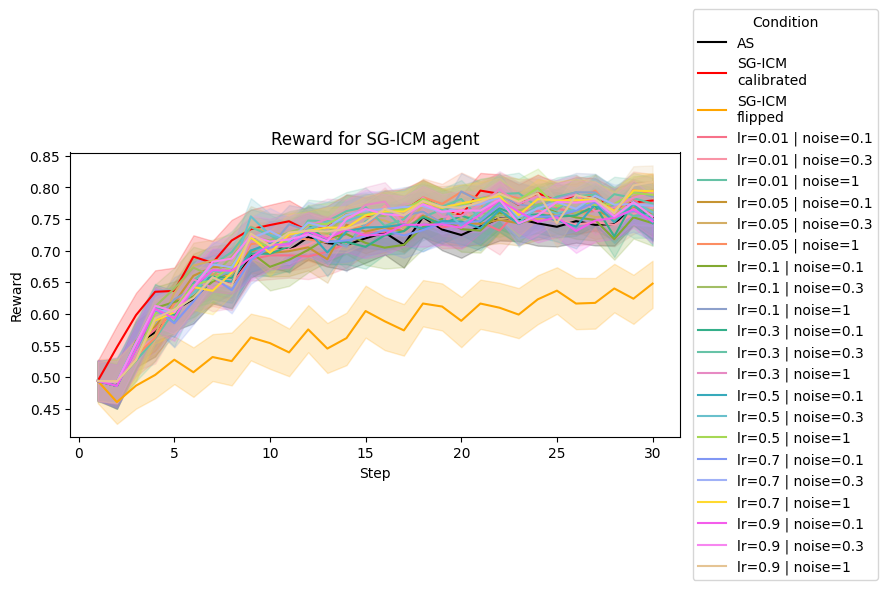

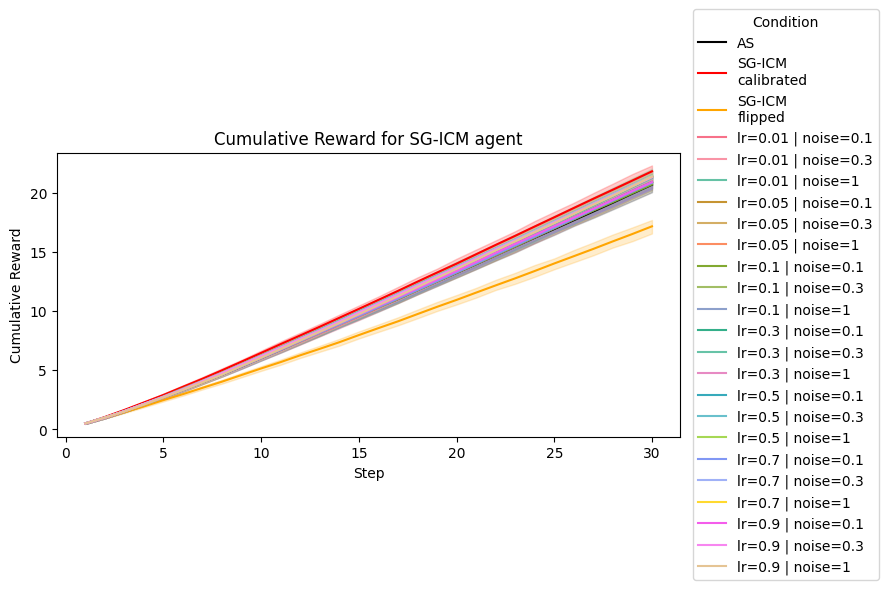

In [ ]:
# # Reward and cumulative reward over time
# plot_reward(results, y_col="reward")
# plot_reward(results, y_col="cumulative_reward")


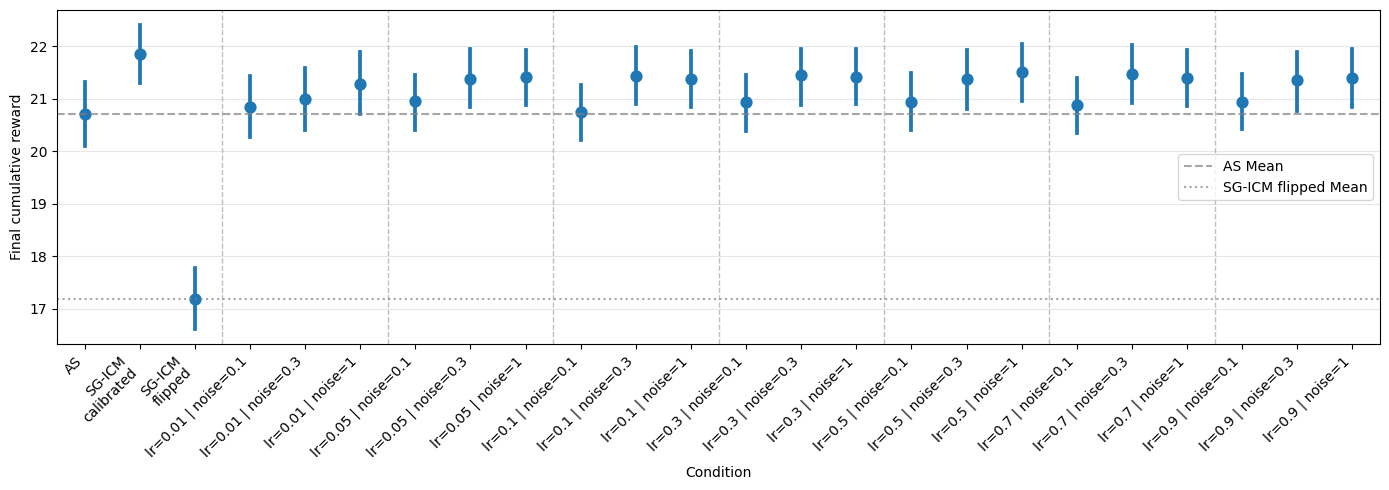

In [20]:
def plot_final_cumreward_catplot(df, x='condition_label'):        
    plot_df = _select_sg_agent(df)                                
    if plot_df.empty:                                             
        print("No data available for plot_final_cumreward_catplot.")                                   
        return                                                    
                                                                
    group_cols = ["seed"]                                         
    if x in plot_df.columns:                                      
        group_cols.append(x)                                      
    final_step = plot_df.groupby(group_cols)["Step"].transform('max')              
    last = plot_df[plot_df['Step'] == final_step].copy()
    last = last.dropna(subset=[x, 'cumulative_reward'])           
    if last.empty:                                                
        print("No final-step data to plot.")                      
        return                                                    
                                                                
    order = sorted(last[x].unique())                              
                                                                
    fig, ax = plt.subplots(figsize=(14, 5))                       
    sns.pointplot(                                                
        data=last,                                                
        x=x,                                                      
        y='cumulative_reward',                                    
        order=order,                                              
        errorbar=('ci', 95),                                      
        dodge=False,                                              
        ax=ax,                                                    
        color='C0',                                               
        linestyles='', 
        markers='o',                                              
    )                                                             
                                                                
    # Add vertical lines to separate different lr values
    prev_lr = None                                                
    first_lr_found = False                                        
    for i, label in enumerate(order):                             
        # Extract lr value from label (format: "lr=X | noise=Y")  
        if "lr=" in label:                                        
            current_lr = label.split("lr=")[1].split(" |")[0]     
                                                                
            # Draw line before the first lr appears               
            if not first_lr_found:                                
                ax.axvline(x=i - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)                           
                first_lr_found = True                             
                                                                
            # Draw line when lr value changes                     
            if prev_lr is not None and current_lr != prev_lr:     
                ax.axvline(x=i - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)                           
            prev_lr = current_lr                                
                                                                
    as_mean = last.loc[last[x] == "AS", "cumulative_reward"].mean()                                       
    flipped_mean = last.loc[last[x] == "SG-ICM\nflipped","cumulative_reward"].mean()                                       
                                                                
    if pd.notna(as_mean):                                         
        ax.axhline(y=as_mean, color='gray', linestyle='--', label='AS Mean', alpha=0.7)                                       
                                                                
    if pd.notna(flipped_mean):                                    
        ax.axhline(y=flipped_mean, color='gray', linestyle=':', label='SG-ICM flipped Mean', alpha=0.7)                           
                                                                
    ax.set_xticks(range(len(order)))                              
    ax.set_xticklabels(order, rotation=45, ha='right') 
    ax.set_xlabel('Condition')                                    
    ax.set_ylabel('Final cumulative reward')                      
    ax.legend()                                                   
    ax.grid(axis='y', alpha=0.3)                                  
    plt.tight_layout()                                            
    plt.show()                                                    
                                                                
plot_final_cumreward_catplot(results) 

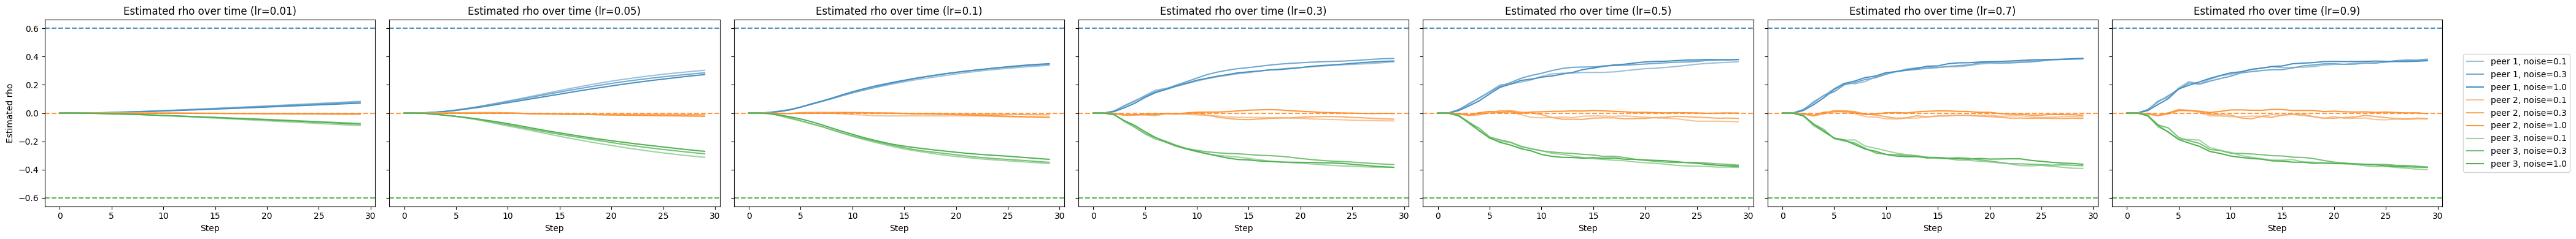

In [13]:
def mean_rho_history(lr=None, noise=None):
    histories = [
        entry["rho_history"]
        for entry in rho_histories
        if (lr is None or entry.get("rho_lr") == lr)
        and (noise is None or entry.get("observation_noise_private") == noise)
    ]
    if not histories:
        return None
    return np.mean(np.stack(histories, axis=0), axis=0)

true_rho = rho_true[1:]

lrs, noises = _unique_lrs_noises(pd.DataFrame(rho_histories))
base_peer_colors = sns.color_palette("tab10", n_colors=max(len(true_rho), 1))
fig, axes = plt.subplots(1, len(lrs), figsize=(6 * max(len(lrs), 1), 4), sharey=True)
if len(lrs) == 1:
    axes = [axes]

for ax, lr in zip(axes, lrs):
    for peer_idx, base_color in enumerate(base_peer_colors):
        shades = sns.light_palette(base_color, n_colors=len(noises) + 3, input="rgb")[2:len(noises)+2]
        for shade, noise in zip(shades, noises):
            mean_hist = mean_rho_history(lr, noise)
            if mean_hist is None:
                continue
            ax.plot(mean_hist[:, peer_idx + 1], color=shade, label=f"peer {peer_idx+1}, noise={noise}")
            ax.axhline(true_rho[peer_idx], linestyle='--', color=base_color, alpha=0.4)
    ax.set_title(f"Estimated rho over time (lr={lr})")
    ax.set_xlabel("Step")

axes[0].set_ylabel("Estimated rho")

handles, labels = axes[-1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[-1].legend(uniq.values(), uniq.keys(), bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.show()


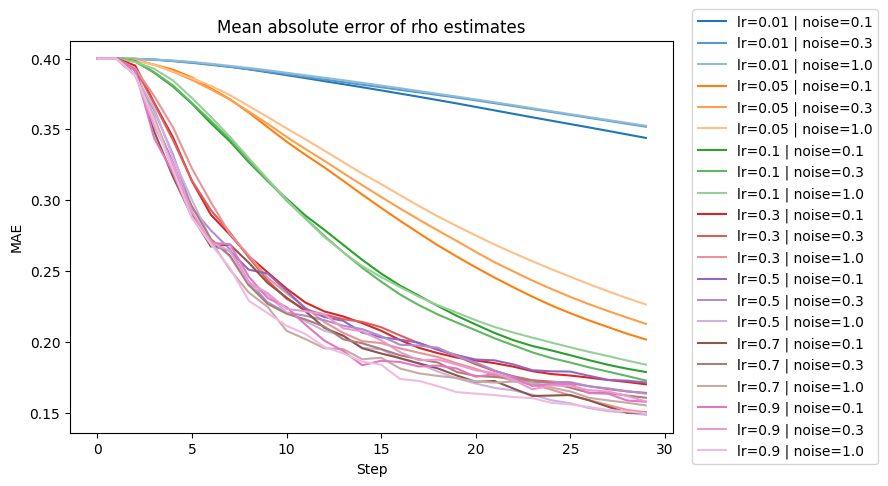

In [14]:
def rho_mae(history):
    est = history[:, 1:]
    return np.mean(np.abs(est - true_rho), axis=1)

lrs, noises = _unique_lrs_noises(results)
base_palette = sns.color_palette("tab10", n_colors=max(len(lrs), 1))
palette = build_lr_noise_palette(results, base_palette)

fig, ax = plt.subplots(figsize=(9, 5))
for label, color in (palette or {}).items():
    lr_val, noise_val = label.replace('lr=', '').split(' | noise=')
    lr_val = float(lr_val)
    noise_val = float(noise_val)
    mean_hist = mean_rho_history(lr_val, noise_val)
    if mean_hist is None:
        continue
    ax.plot(rho_mae(mean_hist), label=label, color=color)

ax.set_title("Mean absolute error of rho estimates")
ax.set_xlabel("Step")
ax.set_ylabel("MAE")
ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


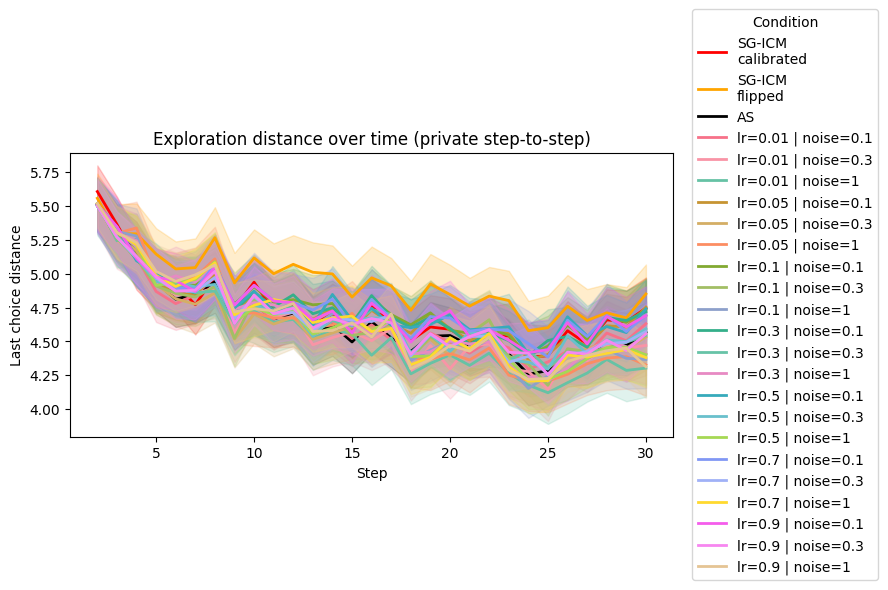

In [15]:
# Extract SG-ICM agent only and filter to Step >= 2
plot_df = results.copy()
plot_df = plot_df[plot_df["Step"] >= 2].copy()

palette = build_lr_noise_palette(plot_df)
if palette:
    # Add colors for base conditions
    base_condition_colors = {
        "AS": "black",
        "SG-ICM\ncalibrated": "red",
        "SG-ICM\nflipped": "orange",
    }
    palette.update(base_condition_colors)
    
    # Check for any remaining missing labels
    missing = [lbl for lbl in sorted(plot_df["condition_label"].unique()) if lbl not in palette]
    if missing:
        extra = sns.color_palette("Set2", n_colors=len(missing))
        palette.update({lbl: col for lbl, col in zip(missing, extra)})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="Step",
    y="last_choice_distance_private",
    hue="condition_label",
    errorbar="ci",
    linewidth=2,
    palette=palette,
)
plt.title("Exploration distance over time (private step-to-step)")
plt.xlabel("Step")
plt.ylabel("Last choice distance")
plt.legend(title="Condition", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

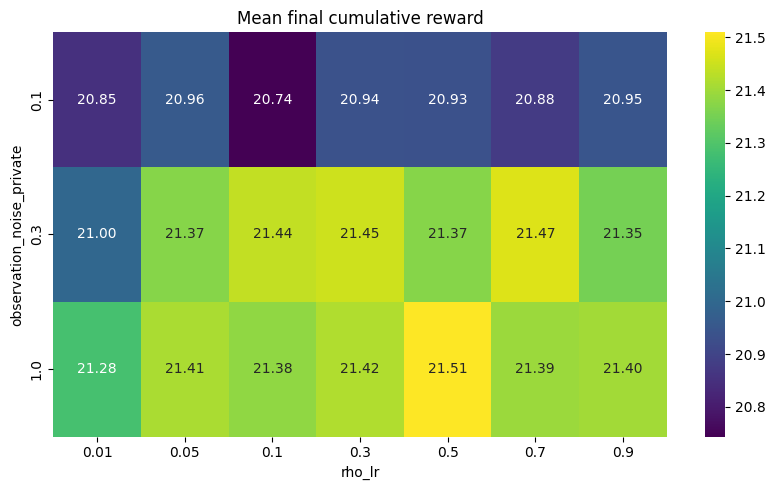

In [16]:
def plot_rho_lr_noise_heatmap(df):
    plot_df = _select_sg_agent(df)
    plot_df = plot_df.dropna(subset=["rho_lr", "observation_noise_private", "cumulative_reward"])
    if plot_df.empty:
        print("No data available for rho_lr/observation_noise_private heatmap.")
        return

    group_cols = ["seed", "rho_lr", "observation_noise_private"]
    final_step = plot_df.groupby(group_cols)["Step"].transform("max")
    final = plot_df[plot_df["Step"] == final_step].copy()
    pivot = final.groupby(["observation_noise_private", "rho_lr"])['cumulative_reward'].mean().reset_index()
    if pivot.empty:
        print("No aggregated data to plot heatmap.")
        return

    table = pivot.pivot(index="observation_noise_private", columns="rho_lr", values="cumulative_reward")
    table = table.sort_index().sort_index(axis=1)

    plt.figure(figsize=(max(6, 1.2 * len(table.columns)), 5))
    sns.heatmap(table, annot=True, fmt=".2f", cmap="viridis")
    plt.xlabel("rho_lr")
    plt.ylabel("observation_noise_private")
    plt.title("Mean final cumulative reward")
    plt.tight_layout()
    plt.show()

plot_rho_lr_noise_heatmap(results)
